# Cultural production by Seshat polity

In [1]:
import math
import sys

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import polars as pl

sys.path.insert(0, '..')
from config import ROOT, SESHAT_DB
from style import *

TICK_SIZE, LABEL_SIZE, TITLE_SIZE = 13, 14, 15
FIRST_YEAR, LAST_YEAR = -500, 1850  # the chart and the top polities stop before LAST_YEAR
POLITIES_XLSX = ROOT / 'external/SeshatDatasetAnalysis/datasets/polities.xlsx'  # output of Seshat's create_polity_dataset.py
UNSEEN_SPECIES = ROOT / 'data/processed/unseen_species.csv'  # output of notebook 01

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(400)
pl.Config.set_fmt_str_lengths(80)
apply_style()

## Data

In [2]:
con = duckdb.connect(str(SESHAT_DB), read_only=True)
individuals = con.execute('''
    SELECT  wikidata_id,
            label_en                                                          AS name,
            list_filter([d.year FOR d IN birth_date], y -> y IS NOT NULL)[1] AS birth_year,
            list_filter([d.year FOR d IN death_date], y -> y IS NOT NULL)[1] AS death_year,
            is_scientist,
            is_artist,
            number_of_works,
            cliopatria_polity.name                                            AS cliopatria_polity,
            s.polity_new_id                                                   AS seshat_id,
            s.polity_long_name                                                AS seshat_name,
            s.macro_region,
            s.home_seshat_region,
            s.home_nga
    FROM    individual, unnest(seshat_polity) AS u(s)
    WHERE   is_scientist OR is_artist
''').pl().with_columns(year=pl.coalesce('death_year', 'birth_year'))

seshat_polities = con.sql('''
    SELECT  polity_new_id    AS seshat_id,
            polity_long_name AS seshat_name,
            start_year       AS period_start,
            end_year         AS period_end,
            macro_region,
            home_seshat_region
    FROM    polity
''').pl()
con.close()

print('rows:', individuals.height, '| individuals:', individuals['wikidata_id'].n_unique(),
      '| Seshat polities:', individuals['seshat_id'].n_unique())
print(seshat_polities.height, 'Seshat polities')
individuals.head()

rows: 1144466 | individuals: 1111405 | Seshat polities: 400
864 Seshat polities


wikidata_id,name,birth_year,death_year,is_scientist,is_artist,number_of_works,cliopatria_polity,seshat_id,seshat_name,macro_region,home_seshat_region,home_nga,year
str,str,i64,i64,bool,bool,i64,str,str,str,str,str,str,i64
"""Q102199704""","""Paul Harper""",1923,2018,true,false,0,"""United States of America""","""us_united_states_of_america_contemporary""","""United States of America - Contemporary""","""North America""","""East Coast""",null,2018
"""Q1021999""","""Yuriko Shiratori""",1983,null,false,true,0,"""Japan""","""jp_japan_contemporary""","""Japan""","""East Asia""","""Northeast Asia""",null,1983
"""Q102200061""","""James Michael Wilson""",1955,null,true,false,0,"""United States of America""","""us_united_states_of_america_contemporary""","""United States of America - Contemporary""","""North America""","""East Coast""",null,1955
"""Q102200119""","""William J. Martin""",1962,null,true,false,0,"""Canada""","""ca_canada_dominion""","""Dominion of Canada""","""North America""","""East Coast""",null,1962
"""Q102200305""","""David Middleton""",1920,2008,true,false,0,"""United States of America""","""us_united_states_of_america_contemporary""","""United States of America - Contemporary""","""North America""","""East Coast""",null,2008


In [3]:
scale_values = (
    pl.from_pandas(pd.read_excel(POLITIES_XLSX, sheet_name='SCV_Imputed', usecols=['PolityName', 'Year', 'Scale_1']))
    .drop_nulls('Scale_1')
)
print(scale_values.height, 'values (start and end year) for', scale_values['PolityName'].n_unique(), 'Seshat polities')
scale_values

1152 values (start and end year) for 576 Seshat polities


PolityName,Year,Scale_1
str,i64,f64
"""cn_qing_dyn_1""",1644,8.069545
"""cn_qing_dyn_1""",1796,8.069545
"""cn_qing_dyn_2""",1796,8.187926
"""cn_qing_dyn_2""",1912,8.253016
"""mx_basin_of_mexico_1""",-6000,3.379456
"""mx_basin_of_mexico_1""",-2001,3.379456
"""mx_basin_of_mexico_2""",-2000,4.005483
"""mx_basin_of_mexico_2""",-1201,4.275095
"""mx_basin_of_mexico_3""",-1200,4.218593


In [4]:
unseen_species = pl.read_csv(UNSEEN_SPECIES)
print(unseen_species.height, 'home region and century rows')
unseen_species

273 home region and century rows


home_seshat_region,century,f0,f0_min,f0_max,f1,f2,f>2
str,i64,f64,f64,f64,i64,i64,i64
"""Afghanistan""",1000,38.055523,6.487113,180.20821,8,2,8
"""Afghanistan""",1100,13.060966,2.156495,62.341071,4,0,1
"""Afghanistan""",1200,7.421355,1.231419,35.700811,2,0,1
"""Afghanistan""",1700,31.517609,5.989796,145.419498,4,0,0
"""Anatolia-Caucasus""",-500,20.154291,2.262442,139.630387,3,0,0
"""Anatolia-Caucasus""",-300,52.203947,22.201452,118.145411,8,0,0
"""Anatolia-Caucasus""",-200,39.694633,17.901008,85.497907,5,0,2
"""Anatolia-Caucasus""",-100,3.824009,1.818332,7.723464,1,0,0
"""Anatolia-Caucasus""",0,4.727017,2.422996,8.956571,1,0,0


## Distribution of Scale_1

statistic,value
str,f64
"""count""",1152.0
"""null_count""",0.0
"""mean""",5.514378
"""std""",1.378451
"""min""",0.699567
"""25%""",4.634785
"""50%""",5.762418
"""75%""",6.498924
"""max""",8.812123


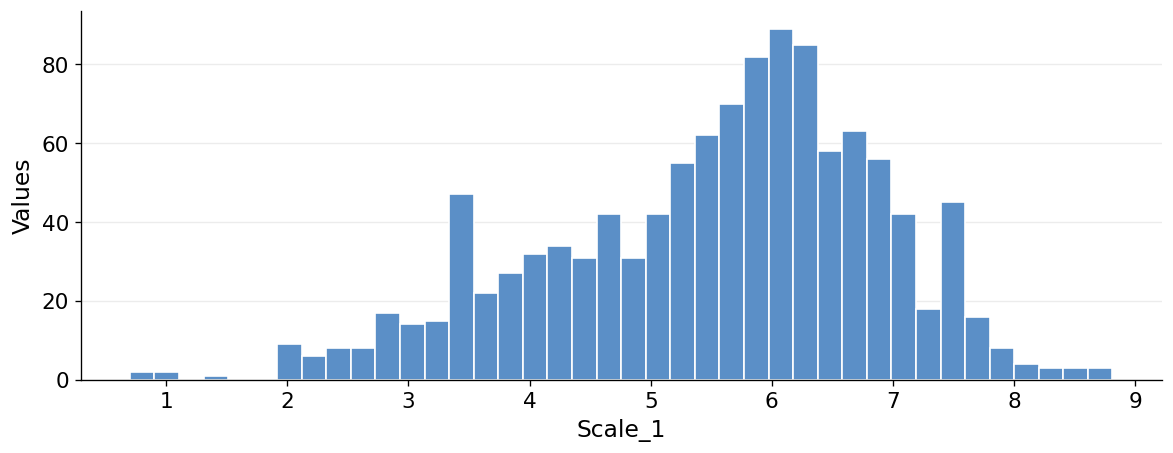

In [5]:
display(scale_values['Scale_1'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scale_values['Scale_1'], bins=40, color=MAIN_COLOR, edgecolor='white')
ax.set_xlabel('Scale_1', fontsize=LABEL_SIZE)
ax.set_ylabel('Values', fontsize=LABEL_SIZE)
ax.tick_params(labelsize=TICK_SIZE)
ax.grid(axis='y', color=GRID_COLOR)
fig.tight_layout()
plt.show()

## By Seshat polity

In [6]:
POLITY_COLUMNS = ['seshat_id', 'seshat_name', 'macro_region', 'home_seshat_region', 'home_nga']

periods_by_polity = seshat_polities.select('seshat_id', 'period_start', 'period_end')

cliopatria = (
    individuals
    .group_by('seshat_id', 'cliopatria_polity').len()
    .sort('len', descending=True)
    .group_by('seshat_id', maintain_order=True)
    .agg(pl.col('cliopatria_polity').str.join(', '))
)

creative = (
    individuals
    .group_by(*POLITY_COLUMNS)
    .agg(
        pl.len().alias('cultural_production'),
        pl.col('is_scientist').sum().alias('scientists'),
        pl.col('is_artist').sum().alias('artists'),
    )
    .join(cliopatria, on='seshat_id')
    .join(periods_by_polity, on='seshat_id', how='left')
    .select('seshat_id', 'seshat_name', 'cliopatria_polity', 'macro_region', 'home_seshat_region', 'home_nga',
            'period_start', 'period_end', 'cultural_production', 'scientists', 'artists')
    .sort('period_start', 'seshat_id')
)
print('rows:', creative.height, '| unique Seshat polities:', creative['seshat_id'].n_unique(),
      '| cultural production:', creative['cultural_production'].sum())
creative

rows: 400 | unique Seshat polities: 400 | cultural production: 1144466


seshat_id,seshat_name,cliopatria_polity,macro_region,home_seshat_region,home_nga,period_start,period_end,cultural_production,scientists,artists
str,str,str,str,str,str,i64,i64,u32,u32,u32
"""eg_dynasty_1""","""Egypt - Dynasty I""","""Early Dynastic Period of Egypt""","""Africa""","""Northeast Africa""","""Upper Egypt""",-3100,-2900,1,1,0
"""eg_dynasty_2""","""Egypt - Dynasty II""","""Early Dynastic Period of Egypt""","""Africa""","""Northeast Africa""","""Upper Egypt""",-2900,-2687,1,1,0
"""eg_old_k_1""","""Egypt - Classic Old Kingdom""","""Old Kingdom of Egypt""","""Africa""","""Northeast Africa""","""Upper Egypt""",-2650,-2350,1,1,0
"""iq_akkad_emp""","""Akkadian Empire""","""Akkadian Empire""","""Southwest Asia""","""Mesopotamia""","""Southern Mesopotamia""",-2270,-2083,1,1,1
"""eg_middle_k""","""Egypt - Middle Kingdom""","""Middle Kingdom of Egypt""","""Africa""","""Northeast Africa""","""Upper Egypt""",-2016,-1700,2,1,1
"""iq_babylonia_2""","""Kassite Babylonia""","""Babylonia""","""Southwest Asia""","""Mesopotamia""","""Southern Mesopotamia""",-1595,-1150,1,1,1
"""eg_new_k_1""","""Egypt - New Kingdom Thutmosid Period""","""New Kingdom of Egypt""","""Africa""","""Northeast Africa""","""Upper Egypt""",-1550,-1293,3,2,2
"""eg_new_k_2""","""Egypt - New Kingdom Ramesside Period""","""New Kingdom of Egypt""","""Africa""","""Northeast Africa""","""Upper Egypt""",-1293,-1070,1,1,0
"""iq_isin_dynasty2""","""Second Dynasty of Isin""","""Babylonia""","""Southwest Asia""","""Mesopotamia""","""Southern Mesopotamia""",-1153,-1027,1,1,1


## Social complexity in China

In [7]:
CHINA = ['North China', 'South China']  # Seshat home regions

# Scale_1 at each polity's start and end year, and the cultural production linked to the polity over that span
scale = (
    scale_values
    .rename({'PolityName': 'seshat_id', 'Year': 'year', 'Scale_1': 'scale'})
    .unique()
    .sort('seshat_id', 'year')
    .group_by('seshat_id', maintain_order=True)
    .agg(start_year=pl.col('year').first(), end_year=pl.col('year').last(),
         scale_start=pl.col('scale').first(), scale_end=pl.col('scale').last())
)
producers = individuals.group_by('seshat_id').agg(cultural_production=pl.len())

names = seshat_polities.select('seshat_id', 'seshat_name', 'macro_region')
china_polities = seshat_polities.filter(pl.col('home_seshat_region').is_in(CHINA)).select('seshat_id')

polities = (
    scale
    .join(names, on='seshat_id', how='left')
    .join(producers, on='seshat_id', how='left')
    .with_columns(pl.col('cultural_production').fill_null(0))
    .select('seshat_id', 'seshat_name', 'macro_region', 'start_year', 'end_year', 'scale_start', 'scale_end', 'cultural_production')
    .sort('start_year', 'seshat_id')
)
complexity = polities.join(china_polities, on='seshat_id').filter(pl.col('start_year') < LAST_YEAR)
first_year = complexity.filter(pl.col('cultural_production') > 0)['start_year'].min()  # the charts start with the first cultural production
complexity = complexity.filter(pl.col('end_year') >= first_year)
print(polities.height, 'Seshat polities with a Scale_1 |', china_polities.height, 'with a home region in', CHINA, '|', complexity.height, 'with a Scale_1 between', first_year, 'and', LAST_YEAR)
complexity

576 Seshat polities with a Scale_1 | 43 with a home region in ['North China', 'South China'] | 28 with a Scale_1 between -780 and 1850


seshat_id,seshat_name,macro_region,start_year,end_year,scale_start,scale_end,cultural_production
str,str,str,i64,i64,f64,f64,u32
"""cn_western_zhou_dyn""","""Western Zhou""","""East Asia""",-1122,-771,6.830957,6.908152,0
"""cn_jin_spring_and_autumn""","""Jin""","""East Asia""",-780,-404,5.957738,5.957738,3
"""cn_chu_dyn_spring_autumn""","""Chu Kingdom - Spring and Autumn Period""","""East Asia""",-740,-489,5.762418,6.179855,4
"""cn_wu_confederacy""","""Wu Confederacy""","""East Asia""",-585,-477,6.020501,6.020501,0
"""cn_yue_dyn""","""Yue Kingdom""","""East Asia""",-510,-334,5.712128,5.712128,1
"""cn_chu_k_warring_states""","""Chu Kingdom - Warring States Period""","""East Asia""",-488,-223,6.602406,6.602406,14
"""cn_eastern_zhou_warring_states""","""Eastern Zhou""","""East Asia""",-475,-256,6.174628,6.174628,0
"""cn_wei_dyn_warring_states""","""Early Wei Dynasty""","""East Asia""",-445,-225,5.848991,5.848991,1
"""cn_qin_emp""","""Qin Empire""","""East Asia""",-338,-207,7.159791,7.450445,3


### Complexity and cultural production

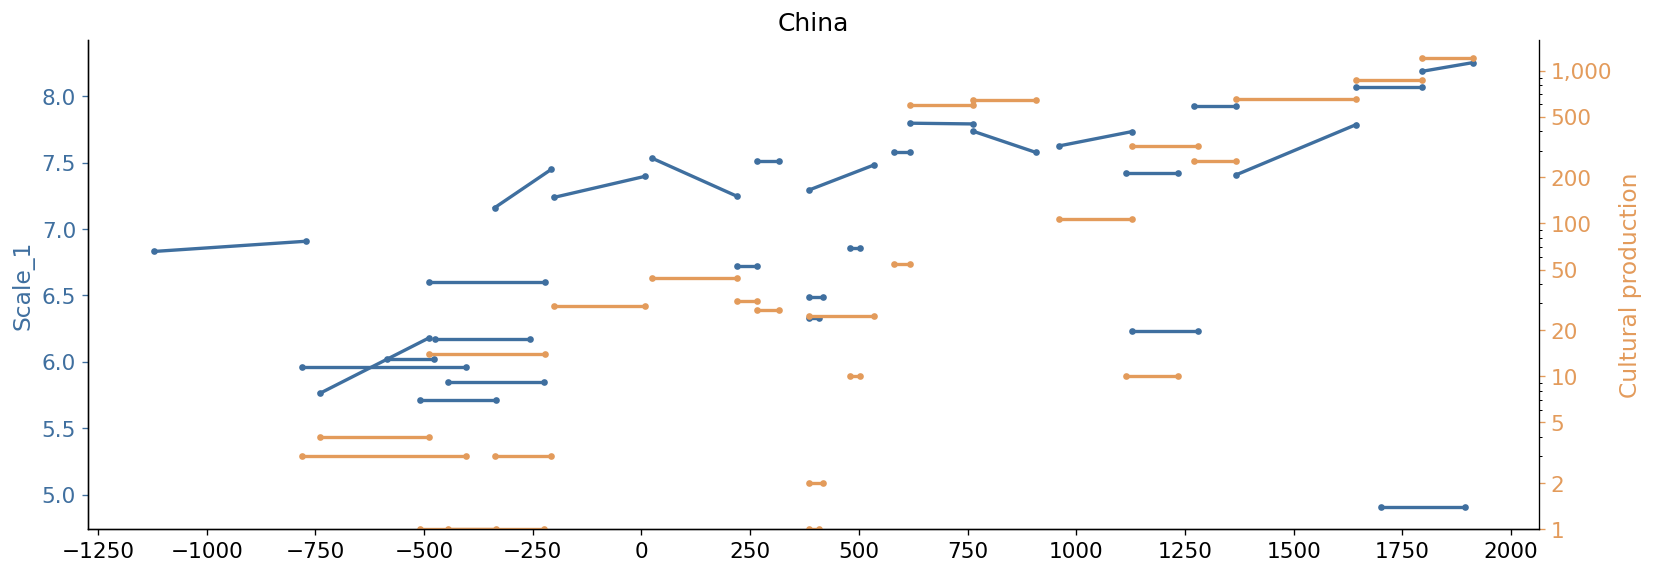

In [8]:
X_TICK_STEP = 250  # years between x ticks


def fit(ax, values, log=False):
    """Stretch an axis to its series' lowest and highest values, so both series fill the same height."""
    low, high = values.drop_nans().min(), values.drop_nans().max()
    if log:
        ax.set_yscale('log')
        ax.set_ylim(1, high * 1.3)  # counts start at 1; below it there is no cultural producer
    else:
        pad = (high - low) * 0.05 or 0.5
        ax.set_ylim(low - pad, high + pad)


def style_axes(ax, right, title, left_label=True, right_label=True):
    """Blue left axis for social scale, orange log right axis for cultural production."""
    ax.xaxis.set_major_locator(ticker.MultipleLocator(X_TICK_STEP))
    ax.tick_params(axis='y', colors=MAIN_LINE_COLOR, labelsize=TICK_SIZE)
    ax.tick_params(axis='x', labelsize=TICK_SIZE)
    ax.set_title(title, fontsize=TITLE_SIZE)
    if left_label:
        ax.set_ylabel('Scale_1', color=MAIN_LINE_COLOR, fontsize=LABEL_SIZE)
    right.yaxis.set_major_locator(ticker.LogLocator(subs=(1, 2, 5)))
    right.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.0f}' if float(v).is_integer() else ''))
    right.yaxis.set_minor_formatter(ticker.NullFormatter())
    right.tick_params(axis='y', colors=ORANGE, labelsize=TICK_SIZE)
    right.spines['right'].set_visible(True)
    if right_label:
        right.set_ylabel('Cultural production', color=ORANGE, fontsize=LABEL_SIZE)



def complexity_and_creative(ax, polities, title, left_label=True, right_label=True):
    """Each polity from its start to its end year: Scale_1 on the left axis, its cultural production on a log right axis."""
    right = ax.twinx()
    for row in polities.iter_rows(named=True):
        span = (row['start_year'], row['end_year'])
        ax.plot(span, (row['scale_start'], row['scale_end']), color=MAIN_LINE_COLOR, linewidth=2, marker='o', markersize=3)
        if row['cultural_production']:
            right.plot(span, (row['cultural_production'],) * 2, color=ORANGE, linewidth=2, marker='o', markersize=3)
    fit(ax, pl.concat([polities['scale_start'], polities['scale_end']]).cast(pl.Float64))
    produced = polities.filter(pl.col('cultural_production') > 0)['cultural_production'].cast(pl.Float64)
    if produced.len():
        fit(right, produced, log=True)
    style_axes(ax, right, title, left_label, right_label)

fig, ax = plt.subplots(figsize=(14, 5))
complexity_and_creative(ax, complexity, 'China')
fig.tight_layout()
plt.show()

### Yearly mean

year,polities,scale,cultural_production
i64,u32,f64,f64
-1122,1,6.830957,0.0
-1121,1,6.831177,0.0
-1120,1,6.831397,0.0
-1119,1,6.831617,0.0
-1118,1,6.831837,0.0
-1117,1,6.832057,0.0
-1116,1,6.832277,0.0
-1115,1,6.832497,0.0
-1114,1,6.832717,0.0


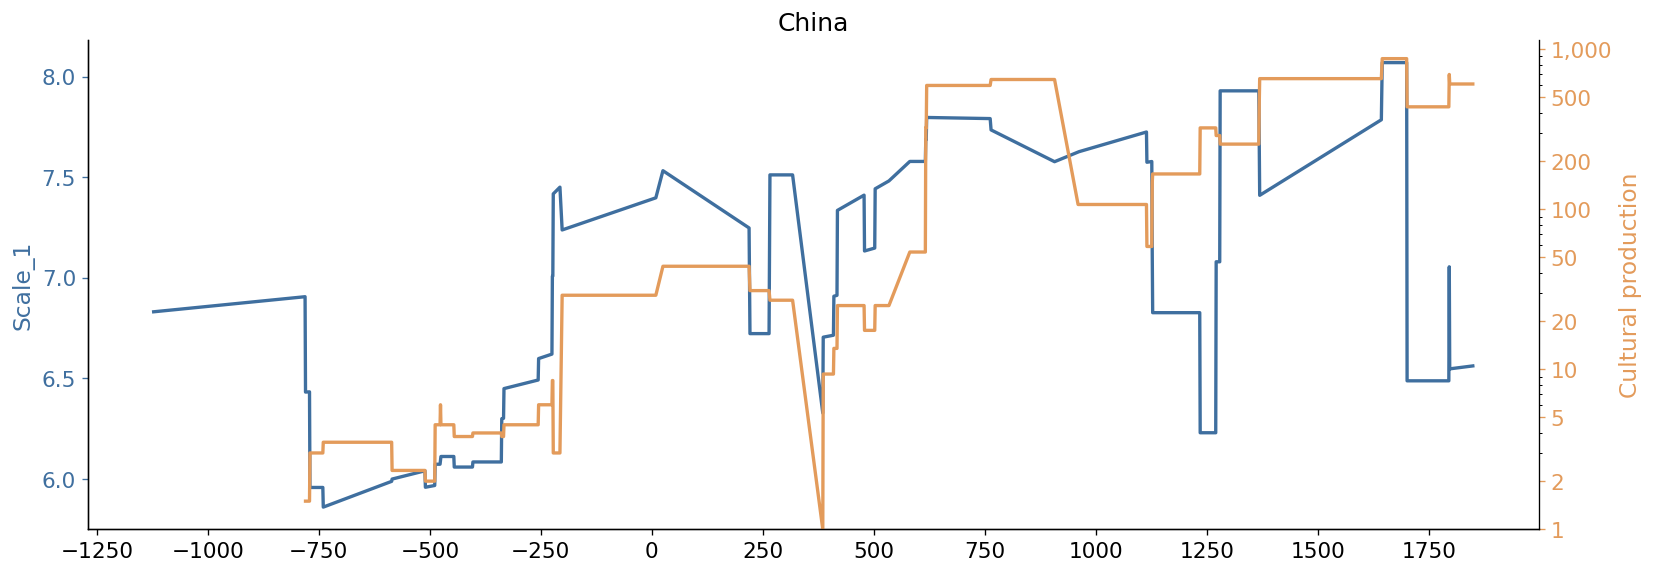

In [9]:
# Every year of every polity: Scale_1 on the line between its start and end values, and the polity's cultural production;
# where polities overlap, the mean of their values
yearly = (
    complexity
    .with_columns(year=pl.int_ranges('start_year', pl.col('end_year') + 1))
    .explode('year')
    .with_columns(scale=pl.when(pl.col('end_year') > pl.col('start_year'))
                  .then(pl.col('scale_start') + (pl.col('scale_end') - pl.col('scale_start'))
                        * (pl.col('year') - pl.col('start_year')) / (pl.col('end_year') - pl.col('start_year')))
                  .otherwise(pl.col('scale_start')))
    .filter(pl.col('year') < LAST_YEAR)
    .group_by('year')
    .agg(polities=pl.len(), scale=pl.col('scale').mean(), cultural_production=pl.col('cultural_production').mean())
    .sort('year')
)
display(yearly)

fig, ax = plt.subplots(figsize=(14, 5))
right = ax.twinx()
ax.plot(yearly['year'], yearly['scale'], color=MAIN_LINE_COLOR, linewidth=2)
producers_line = yearly['cultural_production'].cast(pl.Float64)
producers_line = pl.when(producers_line > 0).then(producers_line).otherwise(None)
producers_line = yearly.select(producers_line.alias('p'))['p'].fill_null(float('nan'))
right.plot(yearly['year'], producers_line, color=ORANGE, linewidth=2)
fit(ax, yearly['scale'].cast(pl.Float64))
fit(right, producers_line.drop_nans(), log=True)
style_axes(ax, right, 'China')
fig.tight_layout()
plt.show()

### Smoothed

year,scale_smooth,cultural_production_smooth
i64,f64,f64
-1122,6.836346,0.0
-1121,6.836456,0.0
-1120,6.836565,0.0
-1119,6.836675,0.0
-1118,6.836785,0.0
-1117,6.836895,0.0
-1116,6.837005,0.0
-1115,6.837115,0.0
-1114,6.837225,0.0


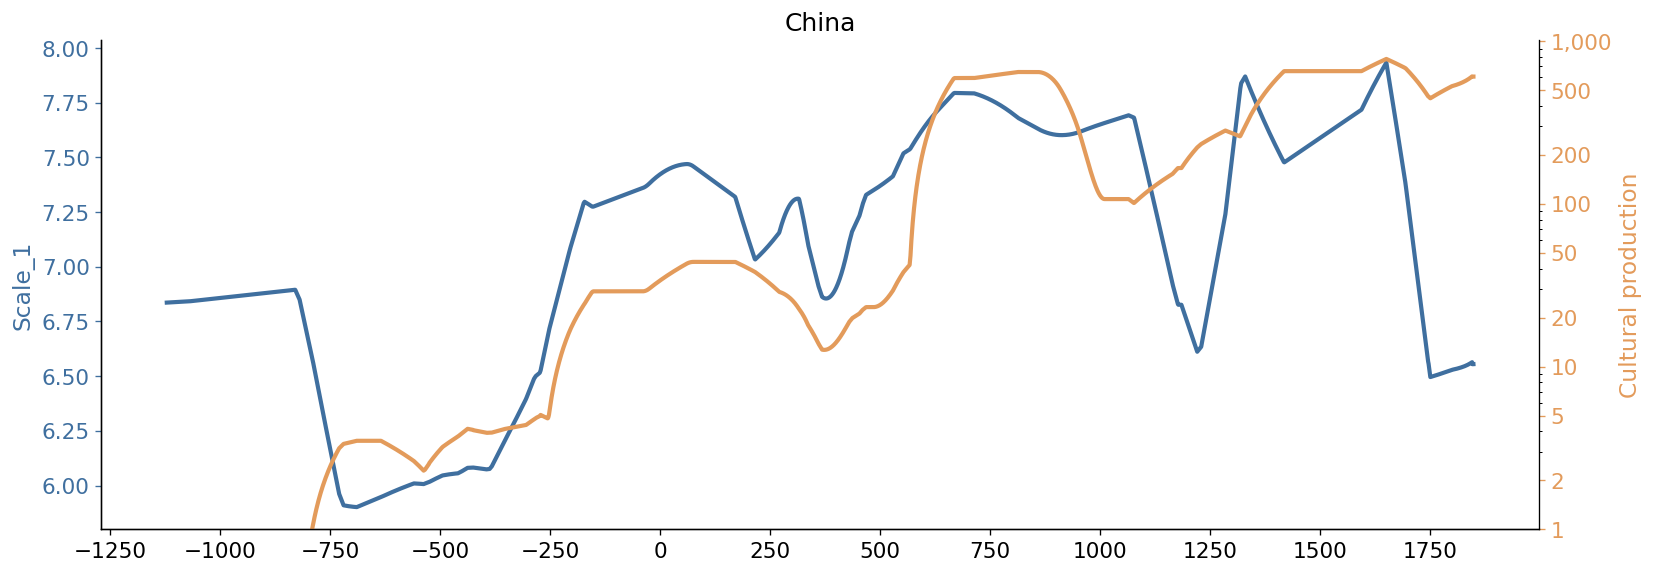

In [10]:
SMOOTH_YEARS = 100  # width of the centred moving average

smooth = (
    pl.DataFrame({'year': range(yearly['year'].min(), yearly['year'].max() + 1)}, schema={'year': yearly.schema['year']})
    .join(yearly, on='year', how='left')
    .with_columns(pl.col('scale').interpolate(), pl.col('cultural_production').interpolate())  # linear imputation of missing years
    .with_columns(
        pl.col('scale').rolling_mean(SMOOTH_YEARS, center=True, min_samples=SMOOTH_YEARS // 2).alias('scale_smooth'),
        pl.col('cultural_production').rolling_mean(SMOOTH_YEARS, center=True, min_samples=SMOOTH_YEARS // 2).alias('cultural_production_smooth'),
    )
    .select('year', 'scale_smooth', 'cultural_production_smooth')
)
display(smooth.drop_nulls())

scale_line = smooth['scale_smooth'].cast(pl.Float64).fill_null(float('nan'))
producers_line = smooth.select(pl.when(pl.col('cultural_production_smooth') > 0).then(pl.col('cultural_production_smooth')))
producers_line = producers_line.to_series().cast(pl.Float64).fill_null(float('nan'))

fig, ax = plt.subplots(figsize=(14, 5))
right = ax.twinx()
ax.plot(smooth['year'], scale_line, color=MAIN_LINE_COLOR, linewidth=2.5)
right.plot(smooth['year'], producers_line, color=ORANGE, linewidth=2.5)
fit(ax, scale_line)
fit(right, producers_line.drop_nans(), log=True)
style_axes(ax, right, 'China')
fig.tight_layout()
plt.show()

In [11]:
CHECK_CENTURIES = range(900, 1900, 100)  # ten centuries to check by hand
TOP = 3  # producers shown per century, by number of works

china_individuals = individuals.join(china_polities, on='seshat_id').with_columns(century=(pl.col('year') // 100) * 100)
top = (
    china_individuals
    .sort('number_of_works', descending=True)
    .group_by('century', maintain_order=True)
    .agg(
        producers=pl.len(),
        top=pl.format('{} ({} works, {})', 'name', 'number_of_works', 'seshat_name').head(TOP).str.join(' | '),
    )
)
check = (
    smooth.filter(pl.col('year').is_in(list(CHECK_CENTURIES)))
    .select('year', smoothed_cultural_production=pl.col('cultural_production_smooth').round(1))
    .join(top, left_on='year', right_on='century', how='left')
    .sort('year')
)
with pl.Config(fmt_str_lengths=300, tbl_width_chars=600):
    display(check)

year,smoothed_cultural_production,producers,top
i64,f64,u32,str
900,554.2,165,"""Luo Yin (343 works, Tang Dynasty II) | Du Guangting (342 works, Five Dynasties Period) | Han Wo (337 works, Tang Dynasty II)"""
1000,112.6,89,"""Wang Yucheng (158 works, Northern Song) | Lin Bu (9 works, Northern Song) | Xu Daoning (8 works, Northern Song)"""
1100,114.6,98,"""Fan Chengda (72 works, Southern Song) | Li Qingzhao (60 works, Southern Song) | Zheng Qiao (45 works, Southern Song)"""
1200,189.4,230,"""Wen Tianxiang (1168 works, Southern Song) | Yuan Haowen (779 works, Jin Dynasty) | Xu Zhao (255 works, Southern Song)"""
1300,272.1,256,"""Liu Ji (734 works, Great Yuan) | Yang Weizhen (604 works, Great Yuan) | Dai Liang (117 works, Great Yuan)"""
1400,580.2,157,"""Ding Henian (70 works, Great Yuan) | Yu Qian (49 works, Great Ming) | Xuande Emperor (41 works, Great Ming)"""
1500,654.0,255,"""Xu Teng (1201 works, Great Ming) | Wen Zhengming (191 works, Great Ming) | Shen Zhou (163 works, Great Ming)"""
1600,666.0,382,"""Zhong Xing (500 works, Great Ming) | Qian Qianyi (348 works, Great Ming) | Yun Shouping (298 works, Early Qing)"""
1700,658.4,529,"""Qianlong Emperor (949 works, Early Qing) | Dong Bangda (402 works, Early Qing) | Fang Bao (358 works, Early Qing)"""


## Social complexity in ancient Greece

In [12]:
GREECE = [
    'gr_crete_nl', 'gr_crete_pre_palace', 'gr_crete_old_palace', 'gr_crete_new_palace', 'gr_crete_mono_palace',
    'gr_crete_post_palace_1', 'gr_crete_post_palace_2', 'gr_crete_geometric', 'gr_crete_archaic', 'gr_crete_classical',
    'gr_crete_hellenistic', 'gr_macedonian_emp', 'gr_antigonid_emp', 'tr_lysimachus_k', 'ir_seleucid_emp',
    'eg_ptolemaic_k_1', 'eg_ptolemaic_k_2', 'tr_pergamon_k', 'af_greco_bactrian_k', 'pk_indo_greek_k',
]

greece_all = polities.filter(pl.col('seshat_id').is_in(GREECE))
print(len(GREECE), 'Greek polities |', greece_all.height, 'with a Scale_1 |', greece_all['cultural_production'].sum(), 'cultural producers')
first_year = greece_all.filter(pl.col('cultural_production') > 0)['start_year'].min()
greece = greece_all.filter(pl.col('end_year') >= first_year)
greece_all

20 Greek polities | 19 with a Scale_1 | 126 cultural producers


seshat_id,seshat_name,macro_region,start_year,end_year,scale_start,scale_end,cultural_production
str,str,str,i64,i64,f64,f64,u32
"""gr_crete_nl""","""Neolithic Crete""","""Europe""",-7000,-3000,2.276828,3.15443,0
"""gr_crete_pre_palace""","""Prepalatial Crete""","""Europe""",-3000,-1900,4.586178,4.608203,0
"""gr_crete_old_palace""","""Old Palace Crete""","""Europe""",-1900,-1700,5.12417,5.12417,0
"""gr_crete_new_palace""","""New Palace Crete""","""Europe""",-1700,-1450,5.987221,5.987221,0
"""gr_crete_mono_palace""","""Monopalatial Crete""","""Europe""",-1450,-1300,4.825766,4.825766,0
"""gr_crete_post_palace_1""","""Postpalatial Crete""","""Europe""",-1300,-1200,4.226817,4.226817,0
"""gr_crete_post_palace_2""","""Final Postpalatial Crete""","""Europe""",-1200,-1000,3.490058,3.490058,0
"""gr_crete_geometric""","""Geometric Crete""","""Europe""",-1000,-710,4.645778,4.645778,0
"""gr_crete_archaic""","""Archaic Crete""","""Europe""",-710,-500,3.82974,3.82974,0


In [13]:
def yearly_mean(complexity):
    return (
        complexity
        .with_columns(year=pl.int_ranges('start_year', pl.col('end_year') + 1))
        .explode('year')
        .with_columns(scale=pl.when(pl.col('end_year') > pl.col('start_year'))
                      .then(pl.col('scale_start') + (pl.col('scale_end') - pl.col('scale_start'))
                            * (pl.col('year') - pl.col('start_year')) / (pl.col('end_year') - pl.col('start_year')))
                      .otherwise(pl.col('scale_start')))
        .filter(pl.col('year') < LAST_YEAR)
        .group_by('year')
        .agg(polities=pl.len(), scale=pl.col('scale').mean(), cultural_production=pl.col('cultural_production').mean())
        .sort('year')
    )


def smoothed(yearly):
    return (
        pl.DataFrame({'year': range(yearly['year'].min(), yearly['year'].max() + 1)}, schema={'year': yearly.schema['year']})
        .join(yearly, on='year', how='left')
        .with_columns(pl.col('scale').interpolate(), pl.col('cultural_production').interpolate())
        .with_columns(
            pl.col('scale').rolling_mean(SMOOTH_YEARS, center=True, min_samples=SMOOTH_YEARS // 2).alias('scale'),
            pl.col('cultural_production').rolling_mean(SMOOTH_YEARS, center=True, min_samples=SMOOTH_YEARS // 2).alias('cultural_production'),
        )
    )


def plot_smoothed(ax, smooth, title, left_label=True, right_label=True):
    scale_line = smooth['scale'].cast(pl.Float64).fill_null(float('nan'))
    producers_line = smooth.select(pl.when(pl.col('cultural_production') > 0).then(pl.col('cultural_production')))
    producers_line = producers_line.to_series().cast(pl.Float64).fill_null(float('nan'))
    right = ax.twinx()
    ax.plot(smooth['year'], scale_line, color=MAIN_LINE_COLOR, linewidth=2.5)
    right.plot(smooth['year'], producers_line, color=ORANGE, linewidth=2.5)
    fit(ax, scale_line)
    fit(right, producers_line.drop_nans(), log=True)
    style_axes(ax, right, title, left_label, right_label)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(6, integer=True))
    return right

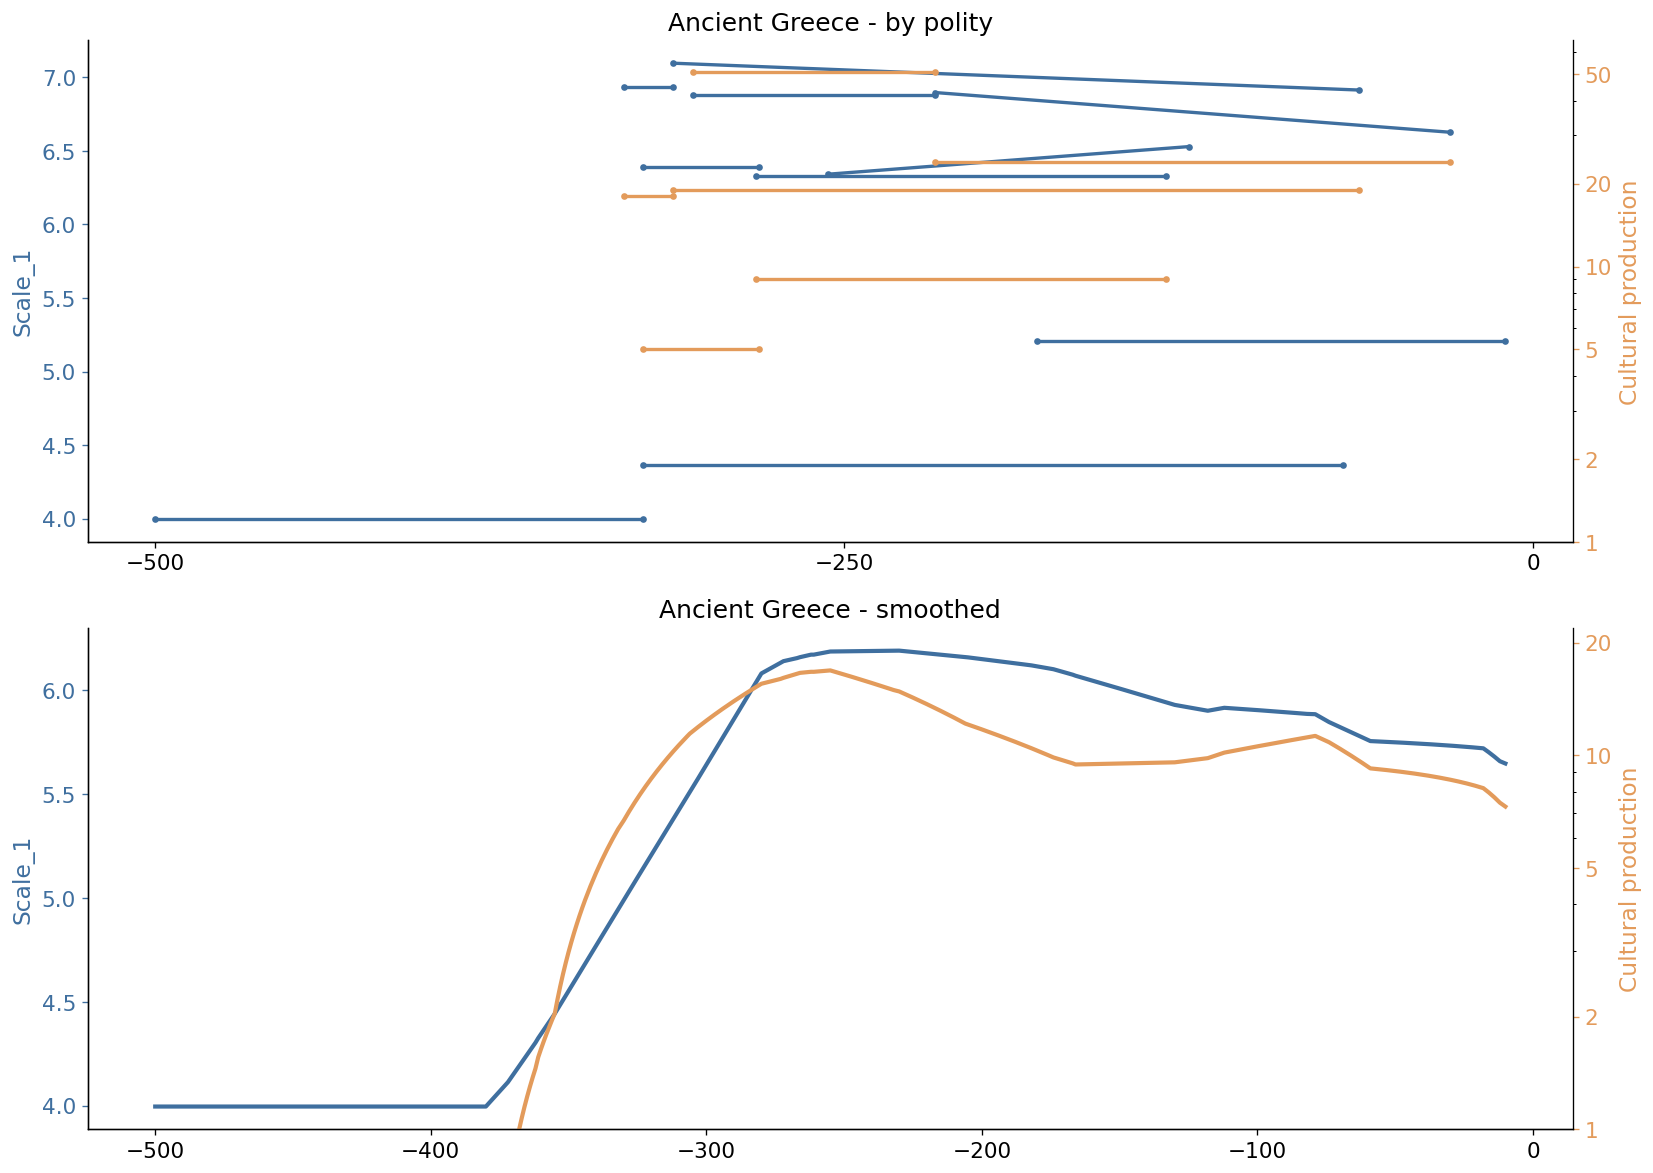

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
complexity_and_creative(axes[0], greece, 'Ancient Greece - by polity')
plot_smoothed(axes[1], smoothed(yearly_mean(greece)), 'Ancient Greece - smoothed')
fig.tight_layout()
plt.show()

## Scale_1 and cultural production by macro region

In [15]:
GRID_LAST_YEAR = 1800
GRID_SIZE = 4  # a 4 x 4 grid of the Seshat regions with the most individuals before LAST_YEAR
top_regions = (
    individuals
    .filter(pl.col('year') < LAST_YEAR)
    .drop_nulls('home_seshat_region')
    .group_by('home_seshat_region').len()
    .sort('len', descending=True)
    .head(GRID_SIZE * GRID_SIZE)
)
display(top_regions)
GRID_REGIONS = {region: pl.col('home_seshat_region') == region for region in top_regions['home_seshat_region']}

regions = seshat_polities.select('seshat_id', 'macro_region', 'home_seshat_region')

home_seshat_region,len
str,u32
"""Central Europe""",21562
"""Western Europe""",20420
"""Southern Europe""",14014
"""Northern Europe""",3814
"""North China""",3715
"""Anatolia-Caucasus""",2828
"""Eastern Europe""",2314
"""Northeast Asia""",1318
"""East Coast""",919


In [16]:
observed = pl.col('f1') + pl.col('f2') + pl.col('f>2')
correction = unseen_species.select('home_seshat_region', 'century', correction=(pl.col('f0') + observed) / observed)

dated = (
    individuals
    .filter(pl.col('year') < GRID_LAST_YEAR)
    .with_columns(century=(pl.col('year') // 100) * 100)
    .join(correction, on=['home_seshat_region', 'century'], how='left')
)
print(dated.height, 'individuals before', GRID_LAST_YEAR, '|', dated['correction'].null_count(),
      'in a home region and century without an unseen estimate, counted once')
production = dated.group_by('seshat_id').agg(
    cultural_production=pl.len(),
    corrected_cultural_production=pl.col('correction').fill_null(1).sum(),
)
production.sort('corrected_cultural_production', descending=True)

54105 individuals before 1800 | 88 in a home region and century without an unseen estimate, counted once


seshat_id,cultural_production,corrected_cultural_production
str,u32,f64
"""de_empire_minor_2""",3702,96671.722619
"""de_empire_minor_1""",3471,83680.718994
"""at_habsburg_2""",2564,66519.917296
"""es_spanish_emp_1""",3729,50823.499445
"""pl_poland_lithuania_commonwealth""",1483,38838.392287
"""fr_bourbon_k_2""",3368,32133.457004
"""at_habsburg_1""",1222,29721.671946
"""sv_swedish_emp""",1402,23442.074498
"""gb_tudor_stuart""",2271,22093.250356


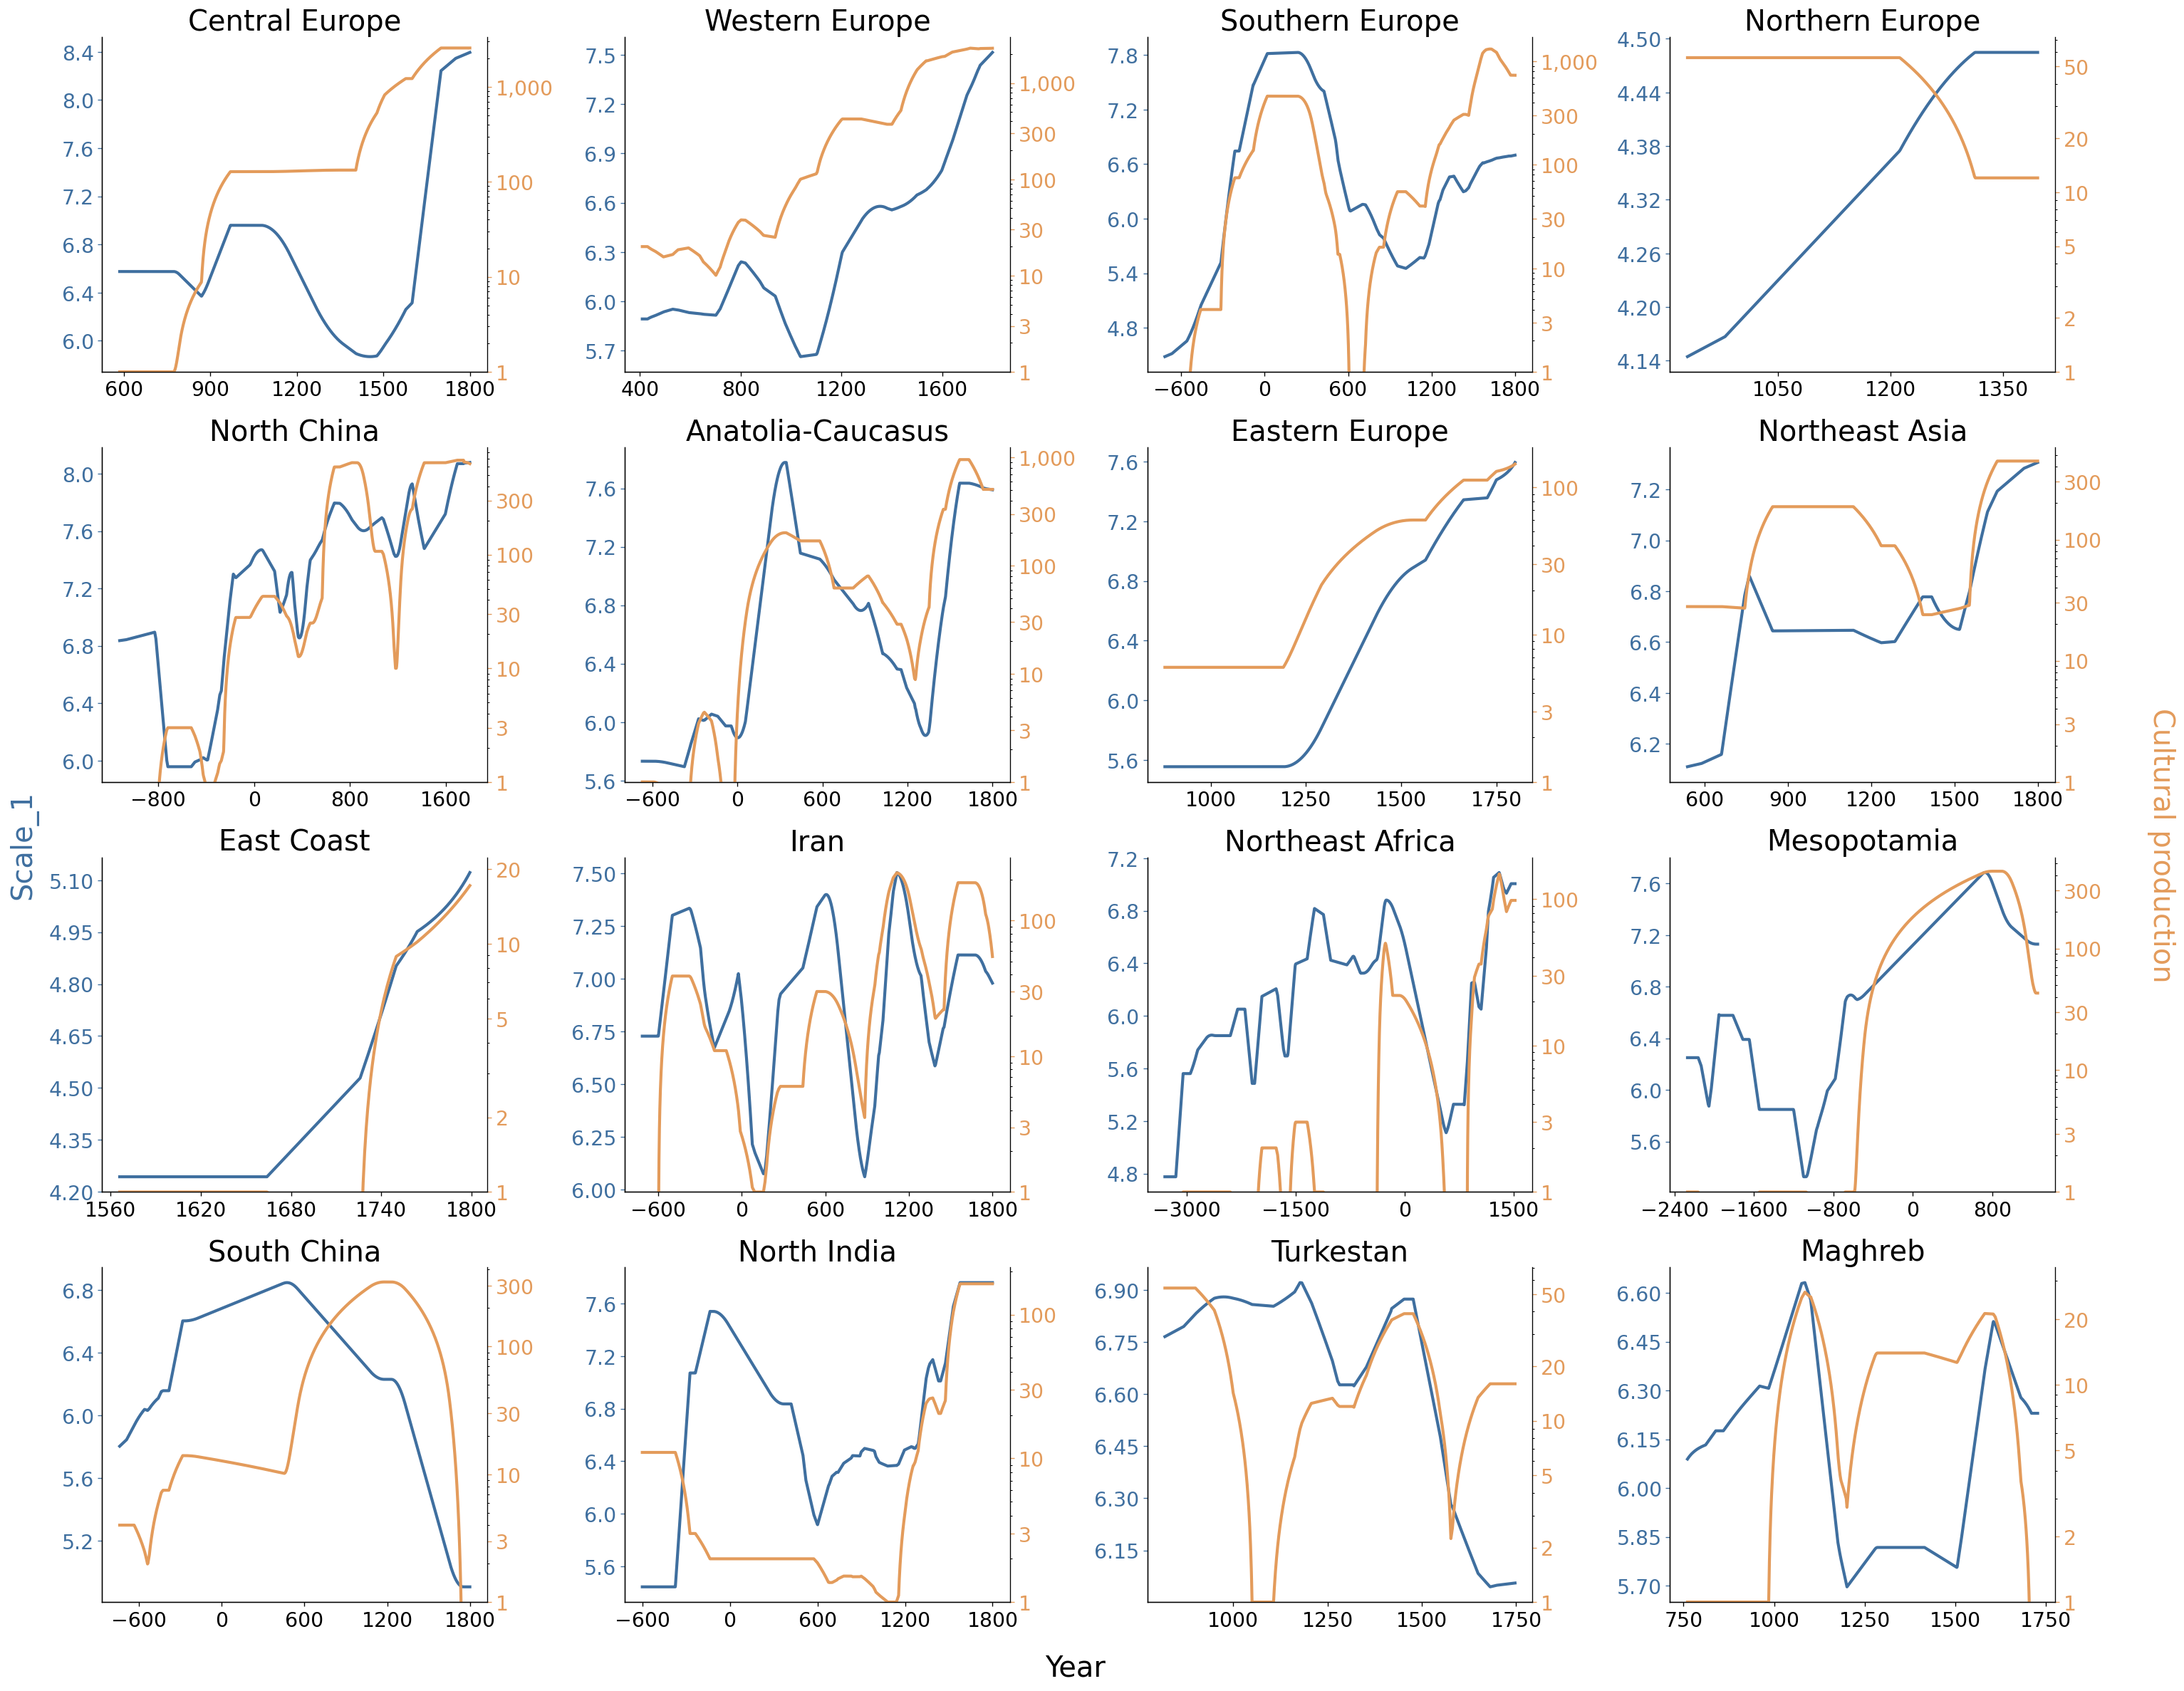

In [17]:
def region_smoothed(region_filter, column):
    region = (
        scale
        .join(regions.filter(region_filter).select('seshat_id'), on='seshat_id')
        .join(production.select('seshat_id', cultural_production=pl.col(column)), on='seshat_id', how='left')
        .with_columns(pl.col('cultural_production').fill_null(0))
        .filter(pl.col('start_year') < GRID_LAST_YEAR)
    )
    first_year = region.filter(pl.col('cultural_production') > 0)['start_year'].min()
    region = region.filter(pl.col('end_year') >= first_year)
    return smoothed(yearly_mean(region).filter(pl.col('year') < GRID_LAST_YEAR))


GRID_TICK_SIZE, GRID_LABEL_SIZE, GRID_TITLE_SIZE = 17, 24, 24


def log_subs(ax):
    """Ticks within each decade of a log axis: more of them when the axis spans few decades."""
    low, high = ax.get_ylim()
    decades = math.log10(high / low)
    return (1,) if decades > 3.5 else (1, 3) if decades > 2 else (1, 2, 5)


def plot_grid(column):
    """One panel per region, with a single x label and a single label for each y axis."""
    columns = GRID_SIZE
    rows = -(-len(GRID_REGIONS) // columns)
    fig, axes = plt.subplots(rows, columns, figsize=(6.5 * columns, 5 * rows))
    for ax, (name, region_filter) in zip(axes.flat, GRID_REGIONS.items()):
        right = plot_smoothed(ax, region_smoothed(region_filter, column), name, left_label=False, right_label=False)
        ax.set_title(name, fontsize=GRID_TITLE_SIZE)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(5, integer=True))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(7))
        right.yaxis.set_major_locator(ticker.LogLocator(subs=log_subs(right)))
        ax.tick_params(labelsize=GRID_TICK_SIZE)
        right.tick_params(labelsize=GRID_TICK_SIZE)
    fig.tight_layout(rect=(0.03, 0.03, 0.97, 1))
    fig.supxlabel('Year', fontsize=GRID_LABEL_SIZE)
    fig.supylabel('Scale_1', color=MAIN_LINE_COLOR, fontsize=GRID_LABEL_SIZE)
    fig.text(0.995, 0.5, column.replace('_', ' ').capitalize(), color=ORANGE, fontsize=GRID_LABEL_SIZE,
             rotation=270, ha='right', va='center')
    plt.show()


plot_grid('cultural_production')

## Scale_1 and corrected cultural production by macro region

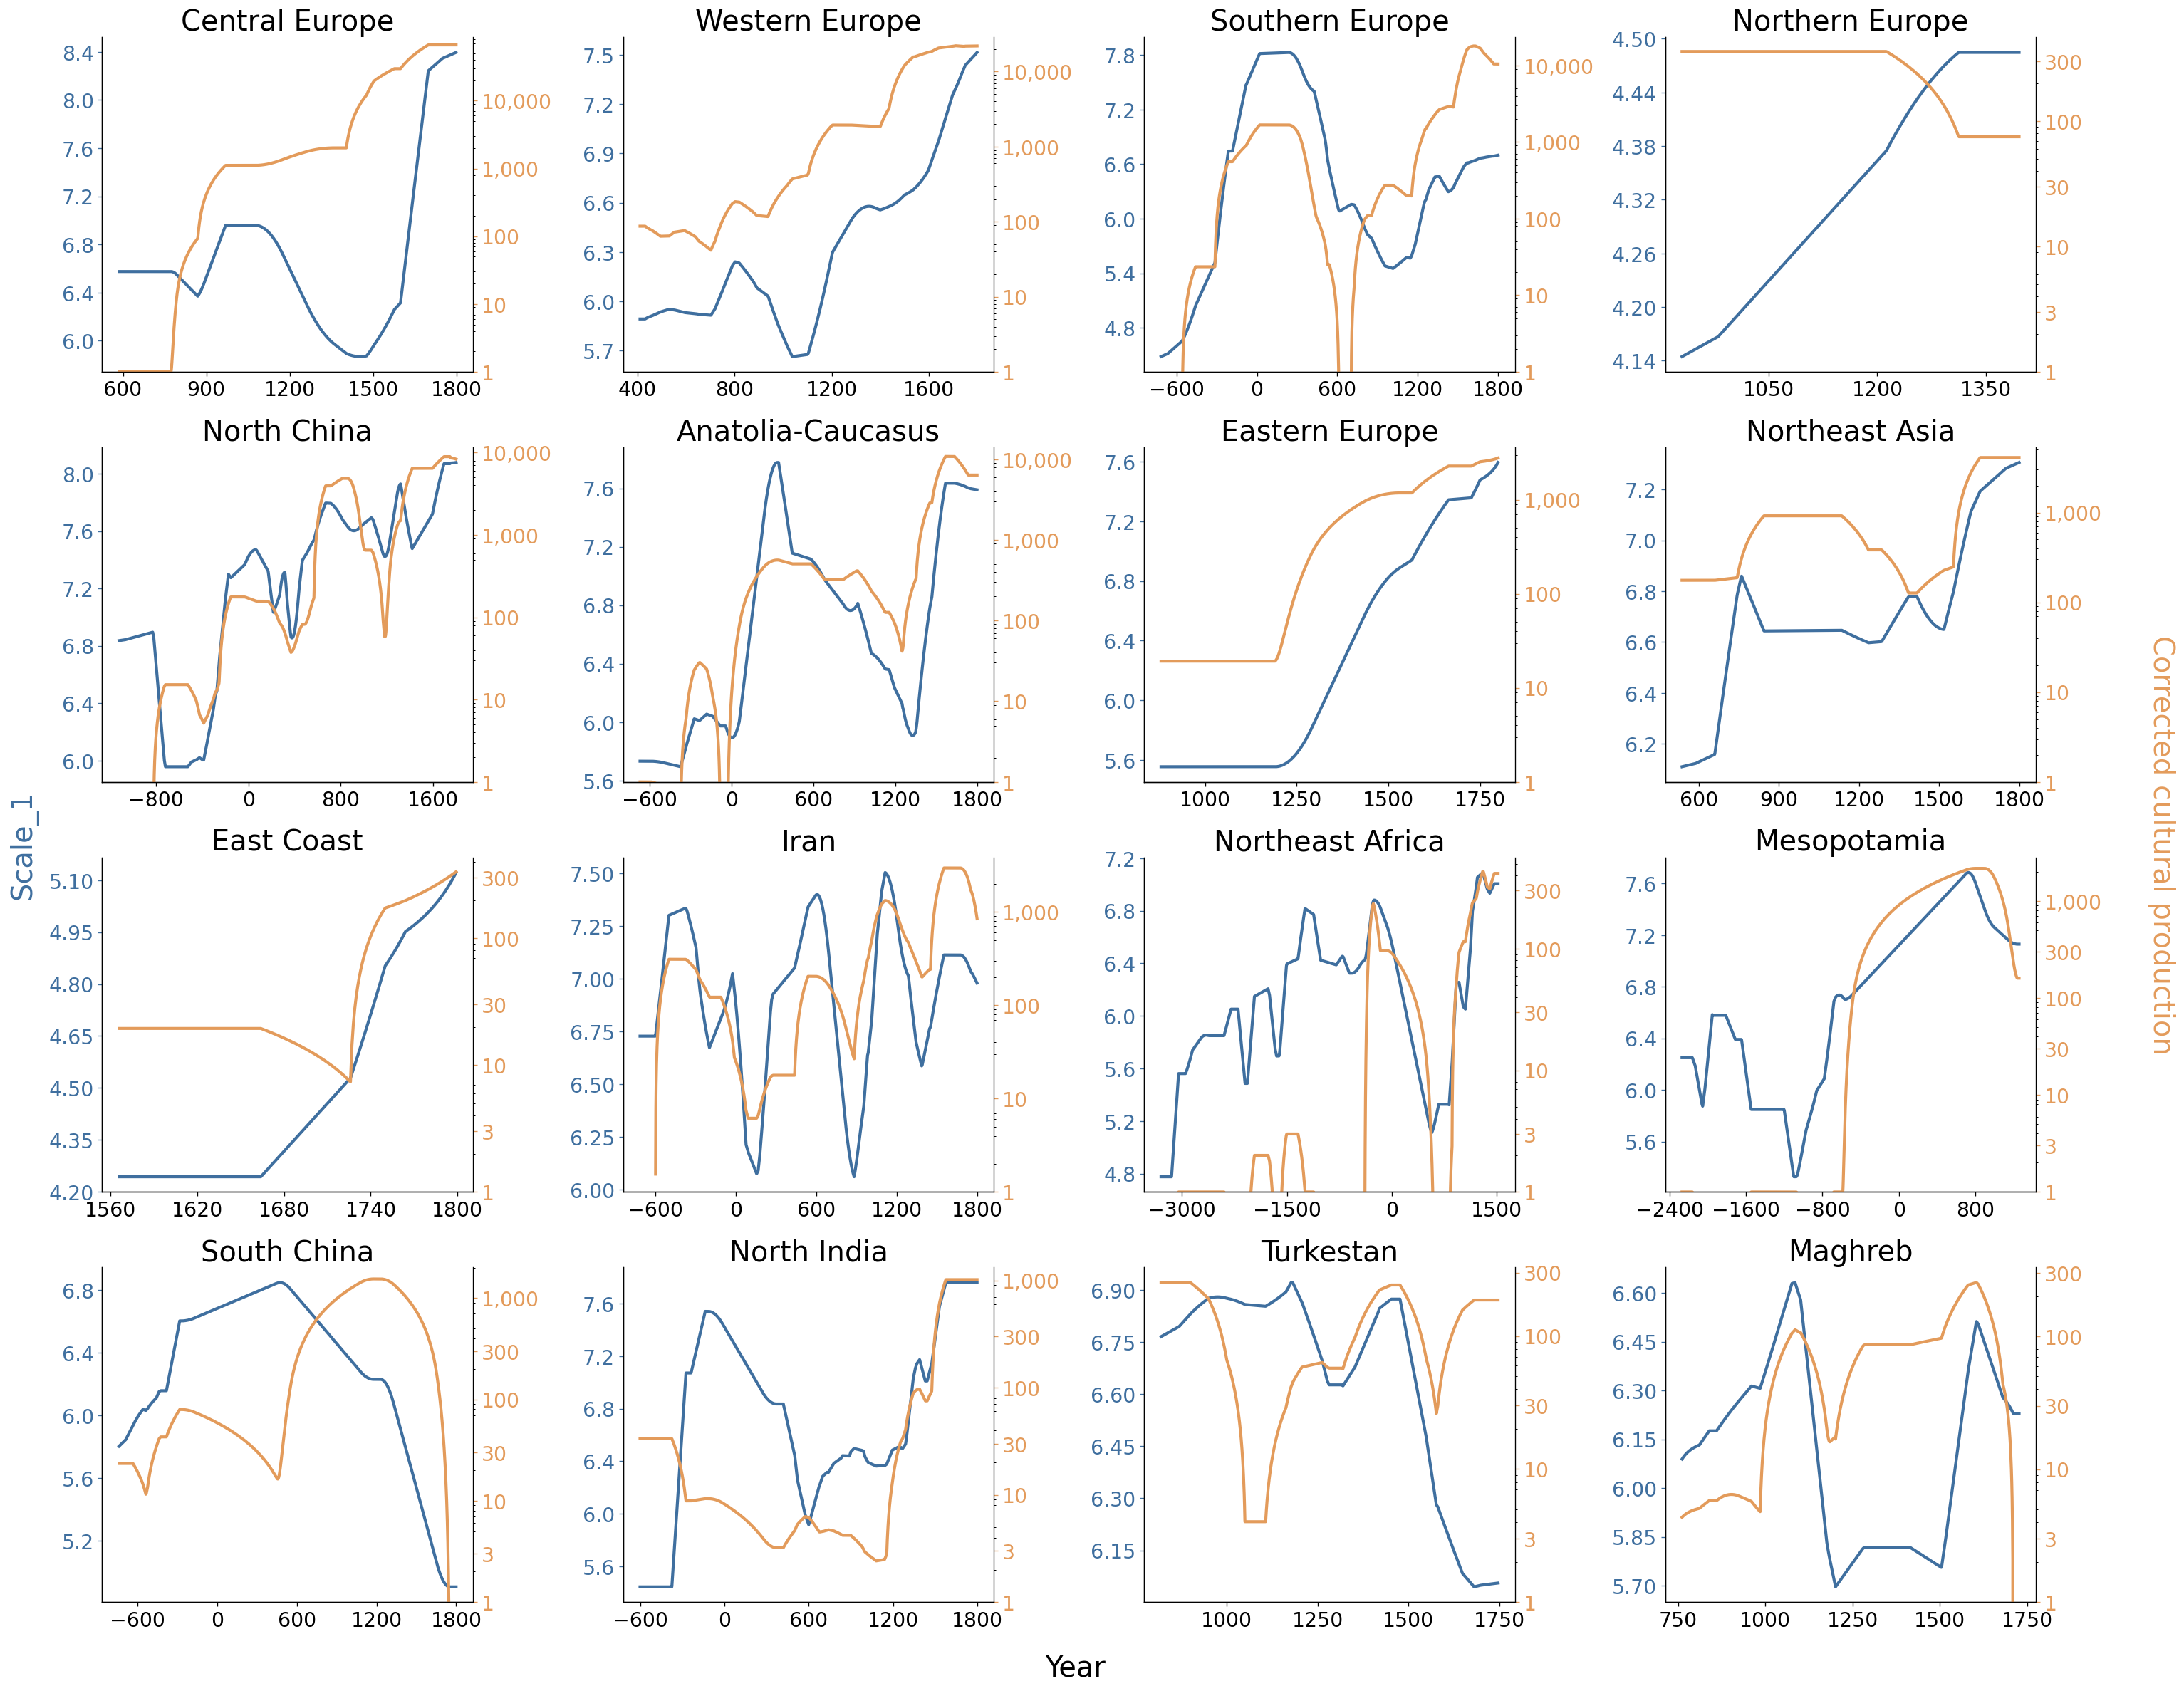

In [18]:
plot_grid('corrected_cultural_production')